# 🎯 Targeted K-Fold Hyperparameter Tuning — DistilBERT Multilingual (Skenario 2)

Fine-tuning `distilbert-base-multilingual-cased` dengan **Targeted K-Fold Cross Validation**  
hanya pada dua hyperparameter paling kritis: `learning_rate` dan `epochs`.

---

## 🧠 Mengapa Targeted (Bukan Full Grid Search)?

Dengan data **~2031 triplet** dan baseline yang sudah bagus, hanya dua HP yang perlu dituning:

| Hyperparameter | Alasan Kritis | Nilai yang Diuji |
|---|---|---|
| `learning_rate` | Data 2× lebih banyak → distribusi gradien berubah | 1e-5, 2e-5, 3e-5, 5e-5 |
| `epochs` | Lebih banyak data → konvergensi lebih cepat per epoch | 2, 3, 4, 6 |

HP lainnya **dikunci di nilai baseline** yang sudah terbukti optimal:

| Hyperparameter | Nilai Dikunci | Alasan |
|---|---|---|
| `batch_size` | 16 | Sudah optimal untuk DistilBERT di T4 |
| `warmup_ratio` | 0.10 | Nilai robust, tidak sensitif terhadap perubahan data |
| `max_seq_length` | 128 | Bergantung panjang teks, bukan jumlah data |

---

## ⏱️ Estimasi Waktu

- **4 × 4 = 16 kombinasi** × 5 fold = **80 run**
- Setiap run DistilBERT ≈ 2–3 menit → total **~3–4 jam** GPU Kaggle T4
- **Tidak ada checkpoint yang disimpan** → storage aman

---

## ✅ Validitas Data

- Training & validasi K-Fold: `triplets_valid_jhpolo_10.csv`
- Evaluasi akhir: `queries_indo.csv` + `qrels.csv` (file berbeda, query berbeda)
- **Tidak ada data leakage** ✅

---
## Cell 1 — Install & Import Library

Downgrade ke `sentence-transformers==3.3.1` karena versi 3.4.1 memiliki bug  
`_nested_gather AttributeError` yang crash saat logging pada model DistilBERT/ModernBERT.

In [4]:
# Downgrade ke 3.3.1 — versi 3.4.1 punya bug _nested_gather yang crash saat logging
!pip install -q sentence-transformers==3.3.1

import os, sys, math, json, warnings
import pandas as pd
import numpy as np
import torch
from datetime import datetime
from sklearn.model_selection import KFold
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

print(f"PyTorch version           : {torch.__version__}")
print(f"GPU tersedia              : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nama GPU                  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total                : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import sentence_transformers
print(f"sentence-transformers ver : {sentence_transformers.__version__}")
print("\n✅ Library siap.")

PyTorch version           : 2.9.0+cu126
GPU tersedia              : True
Nama GPU                  : Tesla T4
VRAM total                : 15.6 GB
sentence-transformers ver : 3.3.1

✅ Library siap.


---
## Cell 2 — Clone Repository & Setup Path

Path output:
- `RESULTS_PATH` → `hp_targeted_kfold_results/` — log JSON hasil semua run
- `BEST_MODEL_PATH` → `best_model_distilbert_targeted/` — model final terbaik

In [5]:
if os.path.exists('skripsi-clir-code'):
    print('Repository ditemukan. Pull...')
    !cd skripsi-clir-code && git pull
else:
    print('Cloning repository...')
    !git clone https://github.com/syifaurrr/skripsi-clir-code.git

REPO_PATH        = './skripsi-clir-code'
SRC_PATH         = os.path.join(REPO_PATH, 'src')
TRAIN_DATA_PATH  = os.path.join(REPO_PATH, 'data', 'training', 'triplets_valid_jhpolo_10.csv')
RESULTS_PATH     = './hp_targeted_kfold_results'
BEST_MODEL_PATH  = './best_model_distilbert_targeted'
RESULTS_LOG_FILE = os.path.join(RESULTS_PATH, 'all_results.json')

sys.path.append(SRC_PATH)
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(BEST_MODEL_PATH, exist_ok=True)

print(f"\nPath Training Data : {TRAIN_DATA_PATH}")
print(f"Path Hasil Tuning  : {RESULTS_PATH}")
print(f"Path Model Terbaik : {BEST_MODEL_PATH}")

Repository ditemukan. Pull...
Already up to date.

Path Training Data : ./skripsi-clir-code/data/training/triplets_valid_jhpolo_10.csv
Path Hasil Tuning  : ./hp_targeted_kfold_results
Path Model Terbaik : ./best_model_distilbert_targeted


---
## Cell 3 — Load Dataset

Dataset training dimuat penuh (`triplets_valid_jhpolo_10.csv`).  
Pembagian fold dilakukan secara dinamis di dalam fungsi K-Fold — tidak ada  
data yang dibuang untuk satu set validasi tetap.

> **Catatan validitas data:**  
> Data ini sepenuhnya terpisah dari `queries_indo.csv` + `qrels.csv` yang dipakai  
> untuk evaluasi akhir — sehingga tidak ada risiko data leakage.

In [6]:
df_full = pd.read_csv(TRAIN_DATA_PATH)
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total triplet      : {len(df_full)}")
print(f"Kolom              : {list(df_full.columns)}")
print(f"\nContoh data:")
display(df_full.head(3))

K_FOLDS   = 5
fold_size = len(df_full) // K_FOLDS
print(f"\nJumlah fold        : {K_FOLDS}")
print(f"Ukuran per fold    : ~{fold_size} sampel")
print(f"Train per fold     : ~{fold_size * (K_FOLDS-1)} sampel")
print(f"Validasi per fold  : ~{fold_size} sampel")

Total triplet      : 2031
Kolom              : ['query', 'tipe_kueri', 'pos_id', 'neg_id', 'pos_text', 'neg_text', 'score_pos', 'score_neg', 'prob_pos', 'prob_neg', 'margin']

Contoh data:


,query,tipe_kueri,pos_id,neg_id,pos_text,neg_text,score_pos,score_neg,prob_pos,prob_neg,margin
0,Apakah istri wajib membayar zakat atas emas ma...,tipe_2,Page_V01P244,Page_V01P247,ولو أصدقها نصاب نقد زكته.\n هو على خلاصه فيجب ...,وجاز لكل إخراج زكاة المشترك بغير إذن الآخر وتو...,-0.380081,-0.827098,0.609930,0.390070,0.219859
1,ijarah barang tetap,tipe_1,Page_V01P375,Page_V01P453,في منفعة متقومة معلومة واقعة للمكتري غير متضمن...,هذا إن فهم كل كلام نفسه وكلام الآخر والشاهدان....,-1.962289,-4.108955,0.895357,0.104643,0.790714
2,Apakah laki-laki diperbolehkan memakai pakaian...,tipe_2,Page_V01P205,Page_V01P211,قال شيخنا: ويكره ما صبغ بعده ولو بغير الحمرة ا...,وحرم تخط لا لمن وجد فرجة قدامه ونحو مبايعة بعد...,-1.110972,-3.094702,0.879078,0.120922,0.758157



Jumlah fold        : 5
Ukuran per fold    : ~406 sampel
Train per fold     : ~1624 sampel
Validasi per fold  : ~406 sampel


---
## Cell 4 — Definisi Grid Targeted

Hanya `learning_rate` dan `epochs` yang divariasikan.  
Semua HP lain dikunci di `FIXED_PARAMS`.

**Mengapa nilai-nilai ini?**
- `learning_rate` : `1e-5` (konservatif) → `5e-5` (agresif), mencakup rentang umum fine-tuning BERT
- `epochs` : `2` (cepat konvergen) → `6` (training lebih lama), untuk melihat titik optimal dengan data 2×

In [7]:
# ============================================================
# HP YANG DITUNING — hanya dua yang paling kritis
# ============================================================
TARGETED_GRID = {
    'learning_rate' : [1e-5, 2e-5, 3e-5, 5e-5],
    'epochs'        : [2, 3, 4, 6],
}

# ============================================================
# HP YANG DIKUNCI — tidak berubah selama tuning
# ============================================================
FIXED_PARAMS = {
    'batch_size'     : 16,    # optimal untuk DistilBERT di T4
    'warmup_ratio'   : 0.10,  # robust, tidak sensitif terhadap perubahan data
    'max_seq_length' : 128,   # bergantung panjang teks, bukan jumlah data
}

BASE_MODEL = 'distilbert-base-multilingual-cased'
# Buat semua kombinasi: 4 lr × 4 epochs = 16 kombinasi
experiment_configs = [
    {**FIXED_PARAMS, 'learning_rate': lr, 'epochs': ep}
    for lr in TARGETED_GRID['learning_rate']
    for ep in TARGETED_GRID['epochs']
]

print(f"Total kombinasi    : {len(experiment_configs)}")
print(f"Total run (×fold)  : {len(experiment_configs) * K_FOLDS}")
print(f"\nHP dikunci:")
for k, v in FIXED_PARAMS.items():
    print(f"  {k:<15} : {v}")
print(f"\nGrid yang dituning:")
display(pd.DataFrame([
    {'learning_rate': c['learning_rate'], 'epochs': c['epochs']}
    for c in experiment_configs
]))

Total kombinasi    : 16
Total run (×fold)  : 80

HP dikunci:
  batch_size      : 16
  warmup_ratio    : 0.1
  max_seq_length  : 128

Grid yang dituning:


,learning_rate,epochs
0,0.00001,2
1,0.00001,3
2,0.00001,4
3,0.00001,6
4,0.00002,2
5,0.00002,3
6,0.00002,4
7,0.00002,6
8,0.00003,2
9,0.00003,3


---
## Cell 5 — Fungsi Utilitas

### `make_dataloader(df, batch_size)`
Konversi DataFrame triplet → DataLoader PyTorch.

### `make_evaluator(df_val)`
Membuat `EmbeddingSimilarityEvaluator` dari fold validasi.  
Setiap triplet → 2 pasang: `(query, pos_text, label=1.0)` dan `(query, neg_text, label=0.0)`.

### `train_one_fold(df_train_fold, df_val_fold, config)`
Training + evaluasi satu fold. **Tidak menyimpan checkpoint** ke disk sama sekali  
(`output_path=None`) untuk menghemat storage Kaggle.

### `run_kfold(config, config_id)`
Menjalankan 5-fold penuh untuk satu konfigurasi. Mengembalikan  
`mean_score ± std_score` dari semua fold.

In [8]:
def make_dataloader(df, batch_size):
    """Konversi DataFrame triplet → DataLoader Sentence-Transformers."""
    examples = [
        InputExample(texts=[str(r['query']), str(r['pos_text']), str(r['neg_text'])])
        for _, r in df.iterrows()
    ]
    return DataLoader(examples, shuffle=True, batch_size=batch_size)


def make_evaluator(df_val):
    """
    Buat EmbeddingSimilarityEvaluator dari fold validasi.
    Setiap triplet → 2 pasang:
      (query, pos_text) → label 1.0  (relevan)
      (query, neg_text) → label 0.0  (tidak relevan)
    Evaluator mengukur Spearman correlation antara prediksi cosine model vs label.
    """
    s1, s2, labels = [], [], []
    for _, row in df_val.iterrows():
        s1.append(str(row['query']));  s2.append(str(row['pos_text'])); labels.append(1.0)
        s1.append(str(row['query']));  s2.append(str(row['neg_text'])); labels.append(0.0)
    return evaluation.EmbeddingSimilarityEvaluator(s1, s2, labels, name='val')


def train_one_fold(df_train_fold, df_val_fold, config):
    """
    Training + evaluasi untuk satu fold.

    Catatan storage: output_path=None → model TIDAK disimpan ke disk.
    Ini mencegah kehabisan storage Kaggle (~400MB × 80 run = ~32GB jika disimpan).

    Return:
        float — skor Spearman Cosine fold ini
    """
    model = SentenceTransformer(BASE_MODEL)
    model.max_seq_length = config['max_seq_length']

    dl             = make_dataloader(df_train_fold, config['batch_size'])
    loss_fn        = losses.MultipleNegativesRankingLoss(model=model)
    total_steps    = len(dl) * config['epochs']
    warmup_steps   = math.ceil(total_steps * config['warmup_ratio'])
    fold_evaluator = make_evaluator(df_val_fold)

    model.fit(
        train_objectives  = [(dl, loss_fn)],
        epochs            = config['epochs'],
        warmup_steps      = warmup_steps,
        optimizer_params  = {'lr': config['learning_rate']},
        show_progress_bar = True,
        output_path       = None,       # tidak simpan ke disk
        save_best_model   = False
    )

    # Tangani return dict (sentence-transformers >= 3.x)
    eval_out = fold_evaluator(model)
    if isinstance(eval_out, dict):
        key   = next((k for k in eval_out if 'spearman_cosine' in k), None)
        score = float(eval_out[key]) if key else float(list(eval_out.values())[0])
    else:
        score = float(eval_out)

    # Bersihkan memory segera setelah evaluasi
    del model, loss_fn, fold_evaluator, dl
    torch.cuda.empty_cache()

    return score


def run_kfold(config, config_id):
    """
    5-Fold Cross Validation untuk satu konfigurasi.

    Return:
        dict — config + mean_score + std_score + skor tiap fold + durasi
    """
    print(f"\n{'='*65}")
    print(f"  {config_id} | lr={config['learning_rate']} | epochs={config['epochs']}")
    print(f"{'='*65}")

    kf          = KFold(n_splits=K_FOLDS, shuffle=False)
    fold_scores = []
    start       = datetime.now()

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df_full), start=1):
        print(f"\n  📂 Fold {fold_idx}/{K_FOLDS} — train: {len(train_idx)}, val: {len(val_idx)}")

        df_train_fold = df_full.iloc[train_idx].reset_index(drop=True)
        df_val_fold   = df_full.iloc[val_idx].reset_index(drop=True)

        score = train_one_fold(df_train_fold, df_val_fold, config)
        fold_scores.append(score)
        print(f"  ✅ Fold {fold_idx} Score: {score:.4f}")

    mean_score = float(np.mean(fold_scores))
    std_score  = float(np.std(fold_scores))
    duration   = (datetime.now() - start).total_seconds() / 60

    print(f"\n  🏁 {config_id} selesai.")
    print(f"     Skor per fold : {[round(s,4) for s in fold_scores]}")
    print(f"     Mean ± Std    : {mean_score:.4f} ± {std_score:.4f}")
    print(f"     Durasi        : {duration:.1f} menit")

    return {
        'config_id'   : config_id,
        'mean_score'  : round(mean_score, 5),
        'std_score'   : round(std_score, 5),
        'fold_scores' : [round(s, 5) for s in fold_scores],
        'duration_min': round(duration, 2),
        **config
    }

print('✅ Fungsi K-Fold siap.')
print(f'   Storage per run: 0 MB (output_path=None)')
print(f'   Storage total  : hanya log JSON + 1 model final')

✅ Fungsi K-Fold siap.
   Storage per run: 0 MB (output_path=None)
   Storage total  : hanya log JSON + 1 model final


---
## Cell 6 — Loop Utama Targeted K-Fold Search

Menjalankan `run_kfold()` untuk semua 16 kombinasi `(learning_rate × epochs)`.

Fitur:
- **Resume capability** — skip konfigurasi yang sudah selesai jika notebook restart
- **Auto-save JSON** — hasil disimpan setelah tiap konfigurasi selesai
- **Error handling** — jika satu konfigurasi error, lanjut ke berikutnya

In [9]:
all_results   = []
completed_ids = set()

if os.path.exists(RESULTS_LOG_FILE):
    with open(RESULTS_LOG_FILE, 'r') as f:
        all_results = json.load(f)
    completed_ids = {r['config_id'] for r in all_results}
    print(f"Resume: {len(all_results)} konfigurasi sudah selesai → {completed_ids}")
else:
    print("Memulai Targeted K-Fold search dari awal...")

total = len(experiment_configs)

for idx, config in enumerate(experiment_configs):
    config_id = f"cfg_{idx+1:03d}"

    if config_id in completed_ids:
        print(f"\n⏭️  [{idx+1}/{total}] {config_id} (lr={config['learning_rate']}, ep={config['epochs']}) — skip.")
        continue

    print(f"\n🚀 [{idx+1}/{total}] {config_id} | lr={config['learning_rate']} | epochs={config['epochs']}")

    try:
        result = run_kfold(config, config_id)
        all_results.append(result)

        with open(RESULTS_LOG_FILE, 'w') as f:
            json.dump(all_results, f, indent=2)
        print(f"  💾 Hasil disimpan ke {RESULTS_LOG_FILE}")

        torch.cuda.empty_cache()

    except RuntimeError as e:
        print(f"\n❌ ERROR pada {config_id}: {e}")
        print("   Lanjut ke konfigurasi berikutnya...")
        torch.cuda.empty_cache()
        continue

print(f"\n\n🎉 Selesai! {len(all_results)}/{total} konfigurasi berhasil.")

Memulai Targeted K-Fold search dari awal...

🚀 [1/16] cfg_001 | lr=1e-05 | epochs=2

  cfg_001 | lr=1e-05 | epochs=2

  📂 Fold 1/5 — train: 1624, val: 407


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  ✅ Fold 3 Score: 0.7528

  📂 Fold 4/5 — train: 1625, val: 406


Step,Training Loss


  ✅ Fold 4 Score: 0.7296

  📂 Fold 5/5 — train: 1625, val: 406


Step,Training Loss


  ✅ Fold 5 Score: 0.7670

  🏁 cfg_016 selesai.
     Skor per fold : [0.7333, 0.7497, 0.7528, 0.7296, 0.767]
     Mean ± Std    : 0.7465 ± 0.0137
     Durasi        : 21.2 menit
  💾 Hasil disimpan ke ./hp_targeted_kfold_results/all_results.json


🎉 Selesai! 16/16 konfigurasi berhasil.


---
## Cell 7 — Analisis Hasil

Ranking berdasarkan `mean_score` (rata-rata 5 fold Spearman Cosine).  
Kolom `std_score` menunjukkan **stabilitas** — nilai kecil = konsisten antar fold.

Karena hanya dua HP yang divariasikan, kita juga membuat **heatmap**  
`learning_rate × epochs` untuk melihat interaksi keduanya secara visual.

In [10]:
import warnings; warnings.filterwarnings('ignore')

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('mean_score', ascending=False).reset_index(drop=True)

print("=" * 65)
print("  HASIL TARGETED K-FOLD — DistilBERT (learning_rate × epochs)")
print("=" * 65)

display_cols = ['config_id', 'mean_score', 'std_score', 'learning_rate', 'epochs', 'duration_min']
display(df_results[display_cols])

best = df_results.iloc[0]
print(f"\n🏆 KONFIGURASI TERBAIK: {best['config_id']}")
print(f"   learning_rate  : {best['learning_rate']}")
print(f"   epochs         : {best['epochs']}")
print(f"   Mean Score     : {best['mean_score']:.5f}")
print(f"   Std Score      : {best['std_score']:.5f}  ({'stabil ✅' if best['std_score'] < 0.05 else 'kurang stabil ⚠️'})")
print(f"   Skor per fold  : {best['fold_scores']}")
print(f"   Durasi         : {best['duration_min']:.1f} menit")
print(f"\n   HP dikunci:")
for k, v in FIXED_PARAMS.items():
    print(f"     {k:<15} : {v}")

# Pengaruh individual tiap HP
print("\n" + "=" * 45)
for param in ['learning_rate', 'epochs']:
    print(f"\n📊 Pengaruh {param}:")
    summary = (
        df_results.groupby(param)['mean_score']
        .agg(['mean', 'max', 'count']).round(5)
        .sort_values('mean', ascending=False)
    )
    summary.columns = ['Rata-rata', 'Tertinggi', 'Jumlah Config']
    display(summary)

  HASIL TARGETED K-FOLD — DistilBERT (learning_rate × epochs)


,config_id,mean_score,std_score,learning_rate,epochs,duration_min
0,cfg_016,0.74649,0.01365,0.00005,6,21.23
1,cfg_015,0.73285,0.01882,0.00005,4,14.38
2,cfg_012,0.72376,0.02278,0.00003,6,21.22
3,cfg_014,0.71509,0.01267,0.00005,3,10.95
4,cfg_011,0.69948,0.01966,0.00003,4,14.37
5,cfg_008,0.69124,0.01741,0.00002,6,21.24
6,cfg_010,0.65666,0.00954,0.00003,3,10.95
7,cfg_007,0.64567,0.01379,0.00002,4,14.37
8,cfg_013,0.64528,0.01952,0.00005,2,7.52
9,cfg_004,0.59602,0.01518,0.00001,6,21.23



🏆 KONFIGURASI TERBAIK: cfg_016
   learning_rate  : 5e-05
   epochs         : 6
   Mean Score     : 0.74649
   Std Score      : 0.01365  (stabil ✅)
   Skor per fold  : [0.73334, 0.74971, 0.75281, 0.72957, 0.76704]
   Durasi         : 21.2 menit

   HP dikunci:
     batch_size      : 16
     warmup_ratio    : 0.1
     max_seq_length  : 128


📊 Pengaruh learning_rate:


,Rata-rata,Tertinggi,Jumlah Config
learning_rate,,,
0.00005,0.70993,0.74649,4
0.00003,0.65863,0.72376,4
0.00002,0.59703,0.69124,4
0.00001,0.46581,0.59602,4



📊 Pengaruh epochs:


,Rata-rata,Tertinggi,Jumlah Config
epochs,,,
6,0.68938,0.74649,4
4,0.64468,0.73285,4
3,0.59562,0.71509,4
2,0.50172,0.64528,4


---
## Cell 8 — Visualisasi Grafik

Tiga grafik:
1. **Heatmap** `learning_rate × epochs` → menampilkan mean_score tiap kombinasi,
   memudahkan melihat kombinasi terbaik sekaligus
2. **Bar chart** pengaruh individual `learning_rate` dan `epochs`
3. **Box plot** distribusi skor fold untuk top-5 konfigurasi terbaik

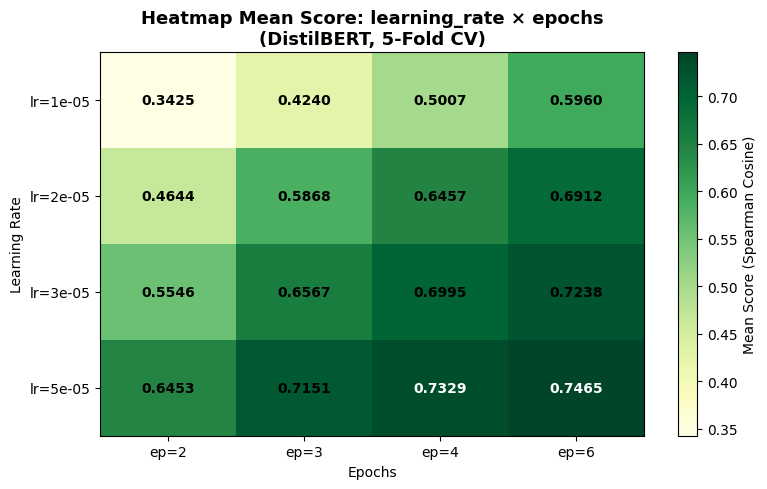

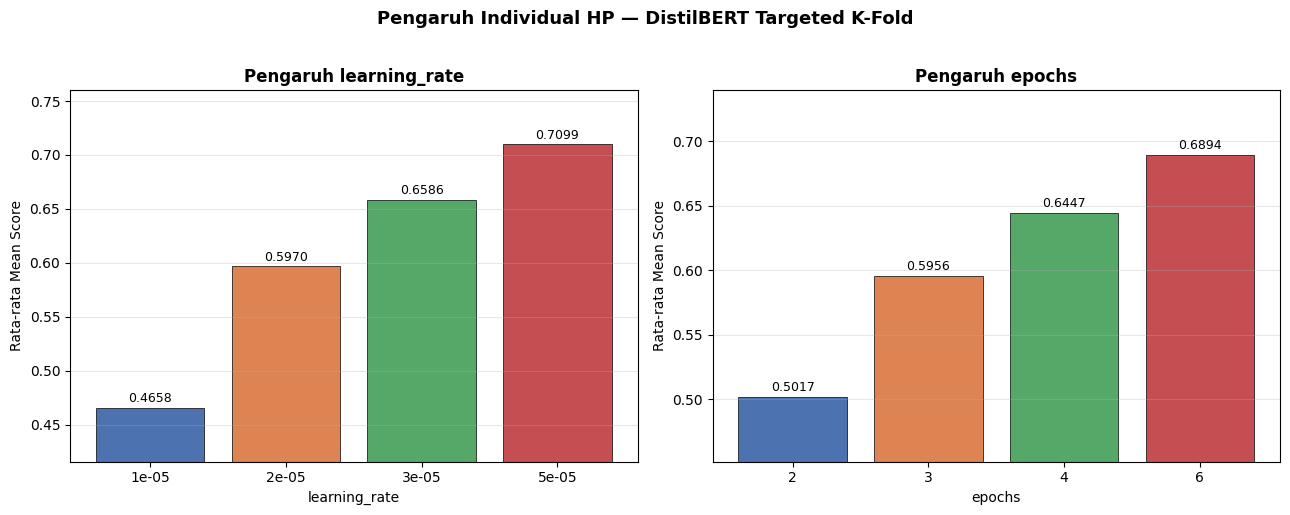

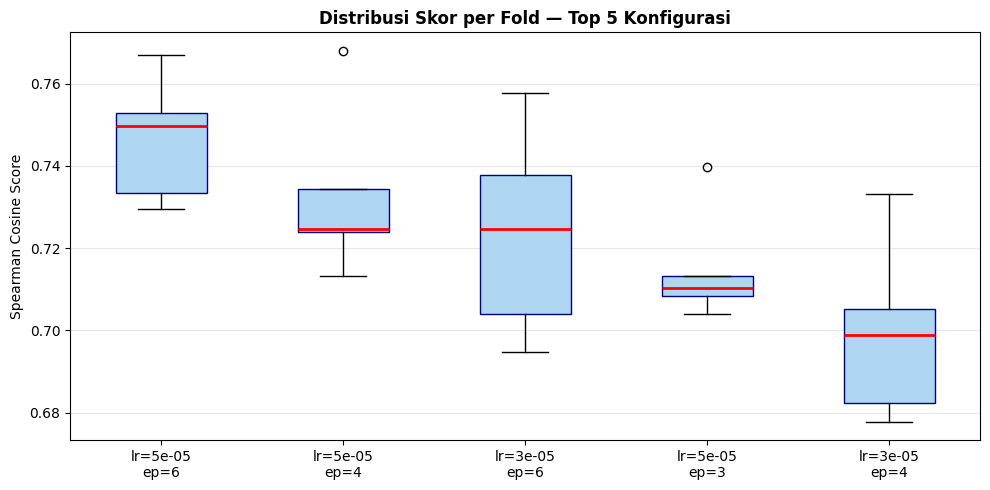

✅ Semua grafik tersimpan.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Grafik 1: Heatmap learning_rate × epochs ──────────────────────────────
pivot = df_results.pivot_table(
    index='learning_rate', columns='epochs', values='mean_score'
)

fig1, ax1 = plt.subplots(figsize=(8, 5))
im = ax1.imshow(pivot.values, cmap='YlGn', aspect='auto')
plt.colorbar(im, ax=ax1, label='Mean Score (Spearman Cosine)')

ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([f"ep={c}" for c in pivot.columns])
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels([f"lr={v:.0e}" for v in pivot.index])

# Annotate setiap cell dengan nilainya
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax1.text(j, i, f'{val:.4f}', ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='black' if val < pivot.values.max() - 0.02 else 'white')

ax1.set_title('Heatmap Mean Score: learning_rate × epochs\n(DistilBERT, 5-Fold CV)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Learning Rate')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'heatmap_lr_epochs.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Grafik 2: Bar chart pengaruh individual ───────────────────────────────
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(13, 5))

# learning_rate
lr_summary = df_results.groupby('learning_rate')['mean_score'].mean().sort_index()
bars_lr = ax2a.bar([f"{v:.0e}" for v in lr_summary.index], lr_summary.values,
                   color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                   edgecolor='black', linewidth=0.5)
for bar, val in zip(bars_lr, lr_summary.values):
    ax2a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
              f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax2a.set_title('Pengaruh learning_rate', fontsize=12, fontweight='bold')
ax2a.set_xlabel('learning_rate'); ax2a.set_ylabel('Rata-rata Mean Score')
ax2a.set_ylim(max(0, lr_summary.min()-0.05), lr_summary.max()+0.05)
ax2a.grid(axis='y', alpha=0.3)

# epochs
ep_summary = df_results.groupby('epochs')['mean_score'].mean().sort_index()
bars_ep = ax2b.bar([str(v) for v in ep_summary.index], ep_summary.values,
                   color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                   edgecolor='black', linewidth=0.5)
for bar, val in zip(bars_ep, ep_summary.values):
    ax2b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
              f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax2b.set_title('Pengaruh epochs', fontsize=12, fontweight='bold')
ax2b.set_xlabel('epochs'); ax2b.set_ylabel('Rata-rata Mean Score')
ax2b.set_ylim(max(0, ep_summary.min()-0.05), ep_summary.max()+0.05)
ax2b.grid(axis='y', alpha=0.3)

plt.suptitle('Pengaruh Individual HP — DistilBERT Targeted K-Fold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'bar_individual_hp.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Grafik 3: Box plot top-5 ──────────────────────────────────────────────
top5 = df_results.head(5)
fold_data = [top5.iloc[i]['fold_scores'] for i in range(len(top5))]
labels = [
    f"lr={top5.iloc[i]['learning_rate']:.0e}\nep={top5.iloc[i]['epochs']}"
    for i in range(len(top5))
]
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.boxplot(fold_data, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='#AED6F1', color='navy'),
            medianprops=dict(color='red', linewidth=2))
ax3.set_title('Distribusi Skor per Fold — Top 5 Konfigurasi',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('Spearman Cosine Score')
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'boxplot_top5.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Semua grafik tersimpan.")

---
## Cell 9 — Retrain Model Terbaik (Full Dataset)

Setelah HP terbaik ditemukan dari K-Fold, latih ulang model dengan **100% data training**.  
Nama file output otomatis mencerminkan HP yang dipakai — mudah diidentifikasi.

In [12]:
best_row = df_results.sort_values('mean_score', ascending=False).iloc[0]

best_config = {
    **FIXED_PARAMS,
    'learning_rate' : float(best_row['learning_rate']),
    'epochs'        : int(best_row['epochs']),
}

# Nama file otomatis mencerminkan HP yang dipakai
auto_name = (
    f"distilbert-multilingual"
    f"_bs{best_config['batch_size']}"
    f"_ep{best_config['epochs']}"
    f"_lr{best_config['learning_rate']}"
    f"_wr{best_config['warmup_ratio']}"
    f"_seq{best_config['max_seq_length']}"
)

print("🏆 Final Training — Konfigurasi Terbaik (Targeted K-Fold)")
print(f"   learning_rate  : {best_config['learning_rate']}")
print(f"   epochs         : {best_config['epochs']}")
print(f"   batch_size     : {best_config['batch_size']}  (dikunci)")
print(f"   warmup_ratio   : {best_config['warmup_ratio']}  (dikunci)")
print(f"   max_seq_length : {best_config['max_seq_length']}  (dikunci)")
print(f"   Mean Score K-Fold : {best_row['mean_score']:.5f} ± {best_row['std_score']:.5f}")
print(f"   Dataset        : {len(df_full)} triplet (full dataset)")
print(f"   Output name    : {auto_name}")

final_model = SentenceTransformer('distilbert-base-multilingual-cased')
final_model.max_seq_length = best_config['max_seq_length']

final_dl     = make_dataloader(df_full, best_config['batch_size'])
final_loss   = losses.MultipleNegativesRankingLoss(model=final_model)
total_steps  = len(final_dl) * best_config['epochs']
warmup_steps = math.ceil(total_steps * best_config['warmup_ratio'])

print(f"\n   Total steps    : {total_steps}")
print(f"   Warmup steps   : {warmup_steps}")
print("\n🔥 Memulai final training...")

os.makedirs(BEST_MODEL_PATH, exist_ok=True)
final_model.fit(
    train_objectives  = [(final_dl, final_loss)],
    epochs            = best_config['epochs'],
    warmup_steps      = warmup_steps,
    optimizer_params  = {'lr': best_config['learning_rate']},
    show_progress_bar = True,
    output_path       = BEST_MODEL_PATH
)

# Simpan ringkasan konfigurasi ke JSON
summary = {
    'model_name'   : 'distilbert-base-multilingual-cased',
    'auto_name'    : auto_name,
    'mean_score'   : best_row['mean_score'],
    'std_score'    : best_row['std_score'],
    'fold_scores'  : best_row['fold_scores'],
    **best_config
}
with open(os.path.join(BEST_MODEL_PATH, 'best_config.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n🎉 ALHAMDULILLAH! Model tersimpan di: '{BEST_MODEL_PATH}'")
print(f"   Nama ZIP nanti : '{auto_name}.zip'")

🏆 Final Training — Konfigurasi Terbaik (Targeted K-Fold)
   learning_rate  : 5e-05
   epochs         : 6
   batch_size     : 16  (dikunci)
   warmup_ratio   : 0.1  (dikunci)
   max_seq_length : 128  (dikunci)
   Mean Score K-Fold : 0.74649 ± 0.01365
   Dataset        : 2031 triplet (full dataset)
   Output name    : distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128



   Total steps    : 762
   Warmup steps   : 77

🔥 Memulai final training...


Step,Training Loss


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]


🎉 ALHAMDULILLAH! Model tersimpan di: './best_model_distilbert_targeted'
   Nama ZIP nanti : 'distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128.zip'


---
## Cell 10 — Ekspor ke ZIP

- `{auto_name}.zip` → model final, nama mencerminkan HP terbaik
- `hp_targeted_kfold_logs.zip` → log JSON + 3 grafik (ukuran kecil)

In [13]:
import shutil, zipfile
from IPython.display import display, FileLink

# ZIP model terbaik dengan nama otomatis
print(f"📦 Mengompres model: {auto_name}...")
shutil.make_archive(auto_name, "zip", BEST_MODEL_PATH)
print(f"✅ {auto_name}.zip siap.")
display(FileLink(auto_name + ".zip"))

# ZIP hanya log + grafik (hemat disk)
print("\n📦 Mengompres log & grafik...")
log_files = ["all_results.json", "heatmap_lr_epochs.png",
             "bar_individual_hp.png", "boxplot_top5.png"]
with zipfile.ZipFile("hp_targeted_kfold_logs.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    for f in log_files:
        fpath = os.path.join(RESULTS_PATH, f)
        if os.path.exists(fpath):
            zf.write(fpath, f)
print("✅ hp_targeted_kfold_logs.zip siap.")
display(FileLink("hp_targeted_kfold_logs.zip"))

# Ringkasan final
print(f"\n{'='*60}")
print("  📊 RINGKASAN AKHIR — Targeted K-Fold")
print(f"{'='*60}")
print(f"  Kombinasi dituning  : {len(df_results)} (lr × epochs)")
print(f"  Jumlah fold         : {K_FOLDS}")
print(f"  Mean score terbaik  : {df_results['mean_score'].max():.5f}")
print(f"  Mean score rata-rata: {df_results['mean_score'].mean():.5f}")
print(f"\n  🏆 HP TERBAIK:")
print(f"     learning_rate  : {best_config['learning_rate']}")
print(f"     epochs         : {best_config['epochs']}")
print(f"     (HP lain dikunci di nilai baseline)")
print(f"\n  Mean Score : {best_row['mean_score']:.5f} ± {best_row['std_score']:.5f}")
print(f"  Fold Scores: {best_row['fold_scores']}")
print(f"\n  File model : {auto_name}.zip")

📦 Mengompres model: distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128...
✅ distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128.zip siap.


/kaggle/working/distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128.zip


📦 Mengompres log & grafik...
✅ hp_targeted_kfold_logs.zip siap.


/kaggle/working/hp_targeted_kfold_logs.zip


  📊 RINGKASAN AKHIR — Targeted K-Fold
  Kombinasi dituning  : 16 (lr × epochs)
  Jumlah fold         : 5
  Mean score terbaik  : 0.74649
  Mean score rata-rata: 0.60785

  🏆 HP TERBAIK:
     learning_rate  : 5e-05
     epochs         : 6
     (HP lain dikunci di nilai baseline)

  Mean Score : 0.74649 ± 0.01365
  Fold Scores: [0.73334, 0.74971, 0.75281, 0.72957, 0.76704]

  File model : distilbert-multilingual_bs16_ep6_lr5e-05_wr0.1_seq128.zip
